# **1. Import Library**

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import ExtraTreesRegressor, RandomForestRegressor
from sklearn.linear_model import ElasticNet, LinearRegression, Ridge
from sklearn.metrics import (
    mean_absolute_error,
    mean_absolute_percentage_error,
    mean_squared_error,
    r2_score,
)
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures
from xgboost import XGBRegressor

from statsmodels.graphics.tsaplots import plot_pacf

# **2. Data Loading**

In [12]:
path = '../data/processed/processed_waste_dataset.csv'

df = pd.read_csv(path)

df.head()

,tanggal,berat_kg,volume_m3,log_volume_m3,is_monday
0,2026-04-18,17.68,0.191651,0.175340,0
1,2026-04-20,36.09,0.594873,0.466794,1
2,2026-04-21,67.05,0.487233,0.396918,0
3,2026-04-22,60.20,0.546106,0.435740,0
4,2026-04-23,18.48,0.293353,0.257238,0


# **3. Feature Engineering**

In [13]:
df = df.sort_values(by="tanggal").reset_index(drop=True)

df["lag_1d"] = df["log_volume_m3"].shift(1)
df["lag_3d"] = df["log_volume_m3"].shift(3)

df["rolling_3d"] = (
    df["log_volume_m3"].shift(1).rolling(window=3).mean()
)

df_model = df.dropna().reset_index(drop=True)

print(f"Jumlah baris setelah windowing: {len(df_model)} baris (Sesuai Rencana)")
df_model[["tanggal", "is_monday", "lag_1d", "lag_3d", "rolling_3d", "log_volume_m3"]].head()

Jumlah baris setelah windowing: 43 baris (Sesuai Rencana)


,tanggal,is_monday,lag_1d,lag_3d,rolling_3d,log_volume_m3
0,2026-04-22,0,0.396918,0.175340,0.346351,0.435740
1,2026-04-23,0,0.435740,0.466794,0.433150,0.257238
2,2026-04-24,0,0.257238,0.396918,0.363298,0.180170
3,2026-04-25,0,0.180170,0.435740,0.291049,0.530455
4,2026-04-27,1,0.530455,0.257238,0.322621,0.568016


## Validasi Feature

/tmp/ipykernel_57107/1286899132.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_model, x="nama_hari", y="volume_m3", order=order_hari, palette="Set2", ax=axes[1], fliersize=0)


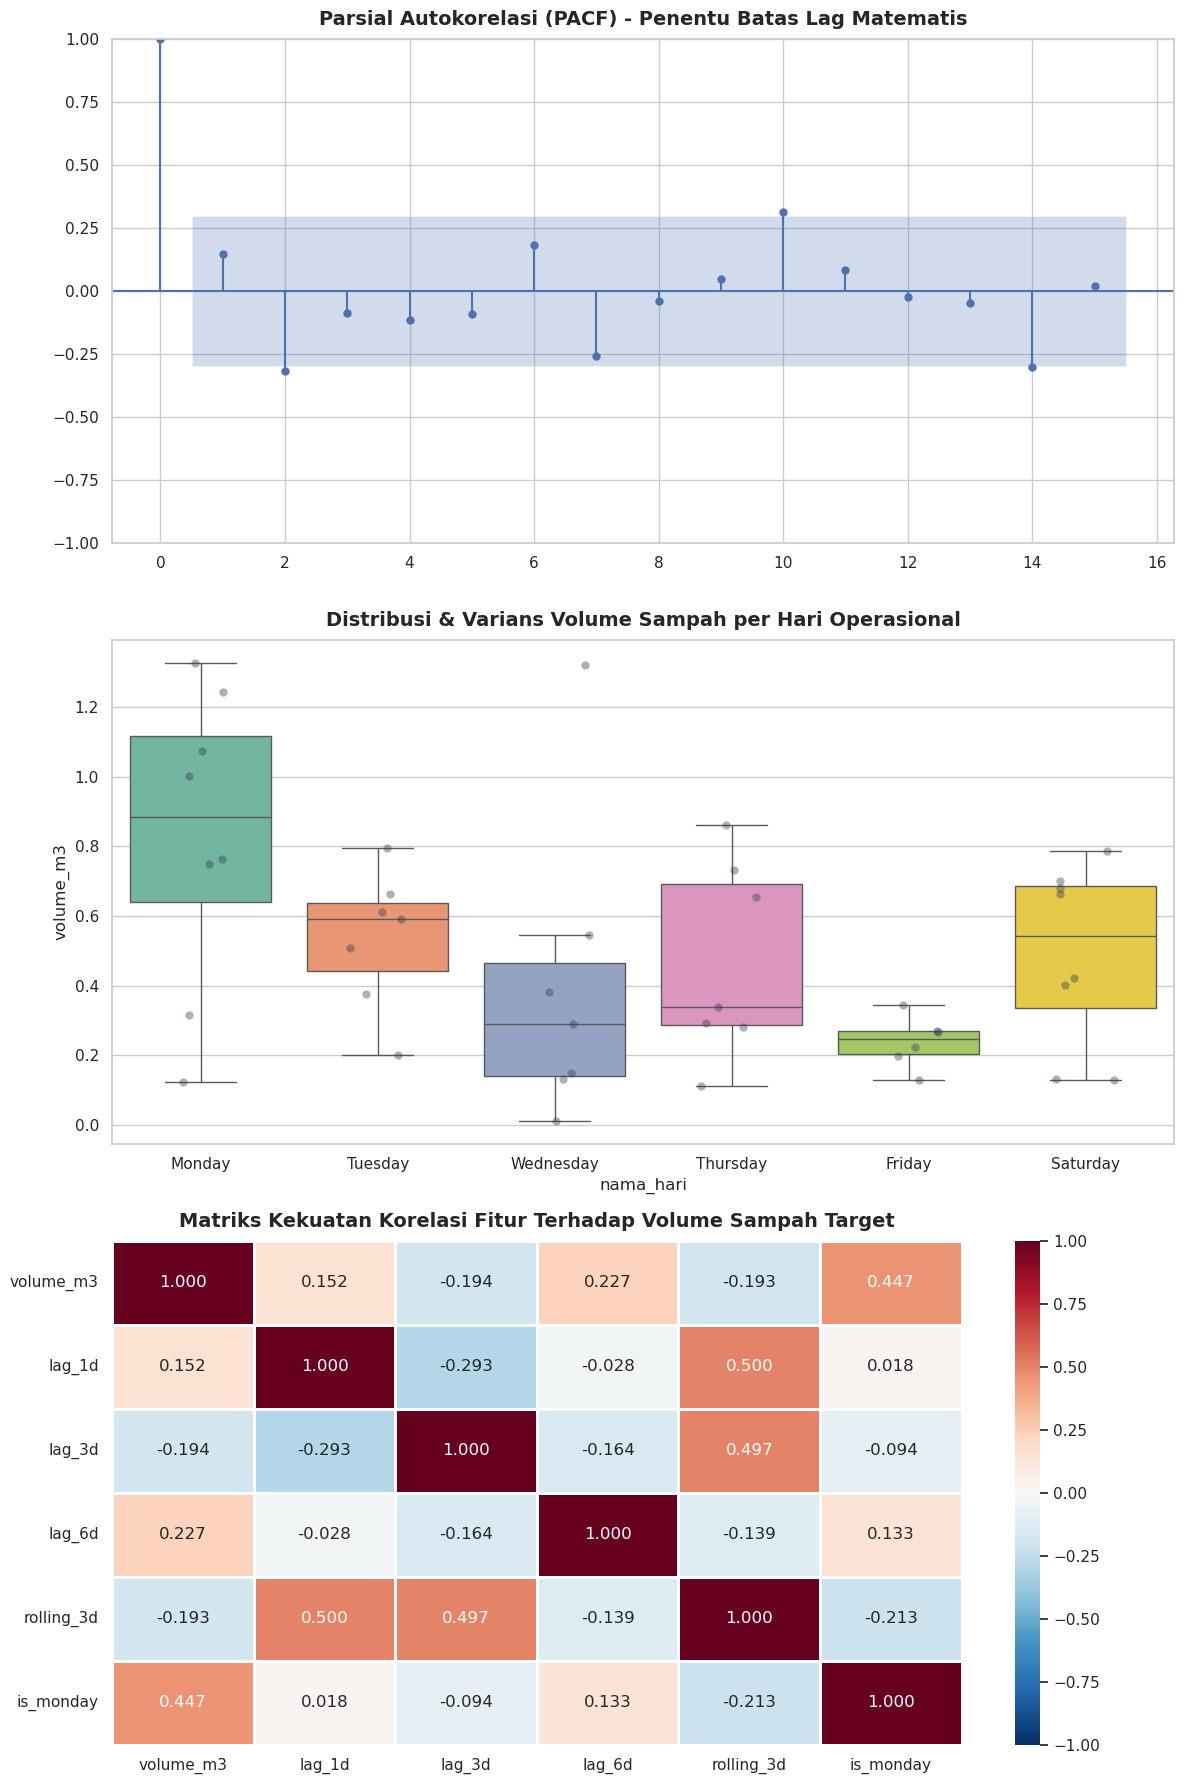

In [14]:
df_model["tanggal"] = pd.to_datetime(df_model["tanggal"])
df_model = df_model.sort_values("tanggal").reset_index(drop=True)

df_model["nama_hari"] = df_model["tanggal"].dt.day_name()
order_hari = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday"]

df_model["lag_6d"] = df_model["volume_m3"].shift(6)

fig, axes = plt.subplots(3, 1, figsize=(12, 18))
sns.set_theme(style="whitegrid")

# PLOT 1: PACF
plot_pacf(df_model["volume_m3"].dropna(), lags=15, ax=axes[0], method="ywm")
axes[0].set_title("Parsial Autokorelasi (PACF) - Penentu Batas Lag Matematis", fontsize=14, fontweight="bold", pad=10)

# PLOT 2: BOXPLOT HARI
sns.boxplot(data=df_model, x="nama_hari", y="volume_m3", order=order_hari, palette="Set2", ax=axes[1], fliersize=0)
sns.stripplot(data=df_model, x="nama_hari", y="volume_m3", order=order_hari, color="#2c3e50", alpha=0.4, size=6, jitter=0.2, ax=axes[1])
axes[1].set_title("Distribusi & Varians Volume Sampah per Hari Operasional", fontsize=14, fontweight="bold", pad=10)

# PLOT 3: HEATMAP KORELASI
fitur_analisis = ["volume_m3", "lag_1d", "lag_3d", "lag_6d", "rolling_3d", "is_monday"]
corr_matrix = df_model[fitur_analisis].corr()
sns.heatmap(corr_matrix, annot=True, cmap="RdBu_r", vmin=-1, vmax=1, fmt=".3f", linewidths=0.8, ax=axes[2])
axes[2].set_title("Matriks Kekuatan Korelasi Fitur Terhadap Volume Sampah Target", fontsize=14, fontweight="bold", pad=10)

plt.tight_layout()
plt.show()

In [15]:
df_model["is_saturday"] = (df_model["nama_hari"] == "Saturday").astype(int)
df_model["is_low_traffic"] = df_model["nama_hari"].isin(["Wednesday", "Friday"]).astype(int)

df_model["lag_9d"] = df_model["volume_m3"].shift(9)

df_model["ewm_3d"] = df_model["volume_m3"].shift(1).ewm(span=3).mean()

df_model_final = df_model.dropna().reset_index(drop=True)

print(f"Data bersih siap pakai: {df_model_final.shape[0]} baris (setelah drop NaN akibat lag).")

Data bersih siap pakai: 34 baris (setelah drop NaN akibat lag).


# **4. Data Splitting**

In [16]:
fitur = ["is_monday", "is_saturday", "is_low_traffic", "lag_6d", "lag_9d", "ewm_3d"]

X = df_model_final[fitur]
y_log = df_model_final["log_volume_m3"]  
y_orig = df_model_final["volume_m3"]     

test_size = 6
split_idx = len(df_model_final) - test_size

X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train_log, y_test_log = y_log.iloc[:split_idx], y_log.iloc[split_idx:]

y_test_orig = y_orig.iloc[split_idx:]
dates_test = df_model_final["tanggal"].iloc[split_idx:]

print("--- Pembagian Dimensi Data (Siklus 1 Minggu Kerja) ---")
print(f"X_train: {X_train.shape} | y_train_log: {y_train_log.shape} -> (Data Training)")
print(f"X_test : {X_test.shape}  | y_test_orig : {y_test_orig.shape} -> (Data Test: 1 Siklus Penuh)")
print(f"Fitur aktif yang digunakan model: {list(X.columns)}")

--- Pembagian Dimensi Data (Siklus 1 Minggu Kerja) ---
X_train: (28, 6) | y_train_log: (28,) -> (Data Training)
X_test : (6, 6)  | y_test_orig : (6,) -> (Data Test: 1 Siklus Penuh)
Fitur aktif yang digunakan model: ['is_monday', 'is_saturday', 'is_low_traffic', 'lag_6d', 'lag_9d', 'ewm_3d']


# **5. Modelling**

In [17]:
models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(alpha=0.1),
    "ElasticNet Regression": ElasticNet(alpha=1.0, l1_ratio=0.5),
    "Polynomial Regression (Deg-2)": make_pipeline(
        PolynomialFeatures(degree=2), LinearRegression()
    ),
    "Random Forest Regressor": RandomForestRegressor(
        n_estimators=100, random_state=42
    ),
    "Extra Trees Regressor": ExtraTreesRegressor(
        n_estimators=100, random_state=42
    ),
    "XGBoost Regressor": XGBRegressor(
        n_estimators=100, learning_rate=0.05, random_state=42
    ),
}

results = []

y_pred_naive_orig = np.expm1(X_test["lag_6d"])

results.append(
    {
        "Model": "Baseline (Naive Predictor)",
        "MAE (m³)": mean_absolute_error(y_test_orig, y_pred_naive_orig),
        "MSE": mean_squared_error(y_test_orig, y_pred_naive_orig),
        "RMSE (m³)": np.sqrt(mean_squared_error(y_test_orig, y_pred_naive_orig)),
        "MAPE (%)": mean_absolute_percentage_error(
            y_test_orig, y_pred_naive_orig
        )
        * 100,
        "R² Score": r2_score(y_test_orig, y_pred_naive_orig),
    }
)

for name, model in models.items():
    model.fit(X_train, y_train_log)

    y_pred_log = model.predict(X_test)

    y_pred_orig = np.expm1(y_pred_log)

    mae = mean_absolute_error(y_test_orig, y_pred_orig)
    mse = mean_squared_error(y_test_orig, y_pred_orig)
    rmse = np.sqrt(mse)
    mape = mean_absolute_percentage_error(y_test_orig, y_pred_orig) * 100
    r2 = r2_score(y_test_orig, y_pred_orig)

    
    results.append(
        {
            "Model": name,
            "MAE (m³)": mae,
            "MSE": mse,
            "RMSE (m³)": rmse,
            "MAPE (%)": mape,
            "R² Score": r2,
        }
    )

print("Proses pelatihan dan evaluasi seluruh model selesai!")

Proses pelatihan dan evaluasi seluruh model selesai!


# **6. Model Evaluation**

In [18]:
df_results = pd.DataFrame(results)

df_results = df_results.sort_values(by="MAE (m³)", ascending=True).reset_index(
    drop=True
)

display(df_results.style.highlight_min(subset=["MAE (m³)", "RMSE (m³)", "MAPE (%)"], color="black"))

,Model,MAE (m³),MSE,RMSE (m³),MAPE (%),R² Score
0,Linear Regression,0.149513,0.048014,0.219120,28.633548,0.584969
1,Ridge Regression,0.149556,0.048950,0.221246,28.392085,0.576877
2,XGBoost Regressor,0.219068,0.176286,0.419865,28.868056,-0.523829
3,ElasticNet Regression,0.241271,0.115884,0.340417,46.904727,-0.001706
4,Random Forest Regressor,0.249836,0.092296,0.303803,52.748227,0.202185
5,Extra Trees Regressor,0.321812,0.190209,0.436130,63.954500,-0.644179
6,Polynomial Regression (Deg-2),0.580605,0.644772,0.802977,128.848178,-4.573441
7,Baseline (Naive Predictor),0.755237,1.134829,1.065284,188.238915,-8.809523


## Visualisasi

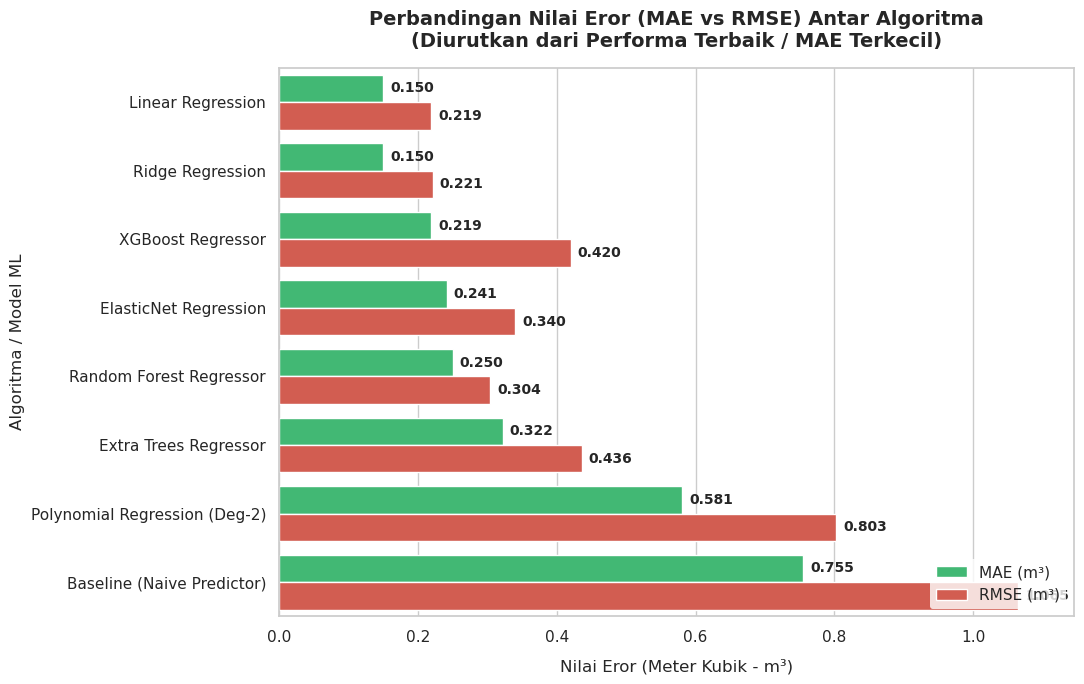

In [19]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(11, 7))

df_sorted = df_results.sort_values(by="MAE (m³)", ascending=True)

df_melted = df_sorted.melt(
    id_vars="Model",
    value_vars=["MAE (m³)", "RMSE (m³)"],
    var_name="Metrik Evaluasi",
    value_name="Nilai Eror (m³)"
)

ax = sns.barplot(
    data=df_melted,
    y="Model",
    x="Nilai Eror (m³)",
    hue="Metrik Evaluasi",
    palette=["#2ecc71", "#e74c3c"]  
)

for container in ax.containers:
    ax.bar_label(container, fmt="%.3f", padding=5, fontsize=10, fontweight="semibold")

plt.title(
    "Perbandingan Nilai Eror (MAE vs RMSE) Antar Algoritma\n(Diurutkan dari Performa Terbaik / MAE Terkecil)",
    fontsize=14,
    fontweight="bold",
    pad=15
)
plt.xlabel("Nilai Eror (Meter Kubik - m³)", fontsize=12, labelpad=10)
plt.ylabel("Algoritma / Model ML", fontsize=12)
plt.xlim(0, df_results["RMSE (m³)"].max() + 0.08) 
plt.legend(loc="lower right", frameon=True, facecolor="white", edgecolor="none")

plt.tight_layout()

plt.show()

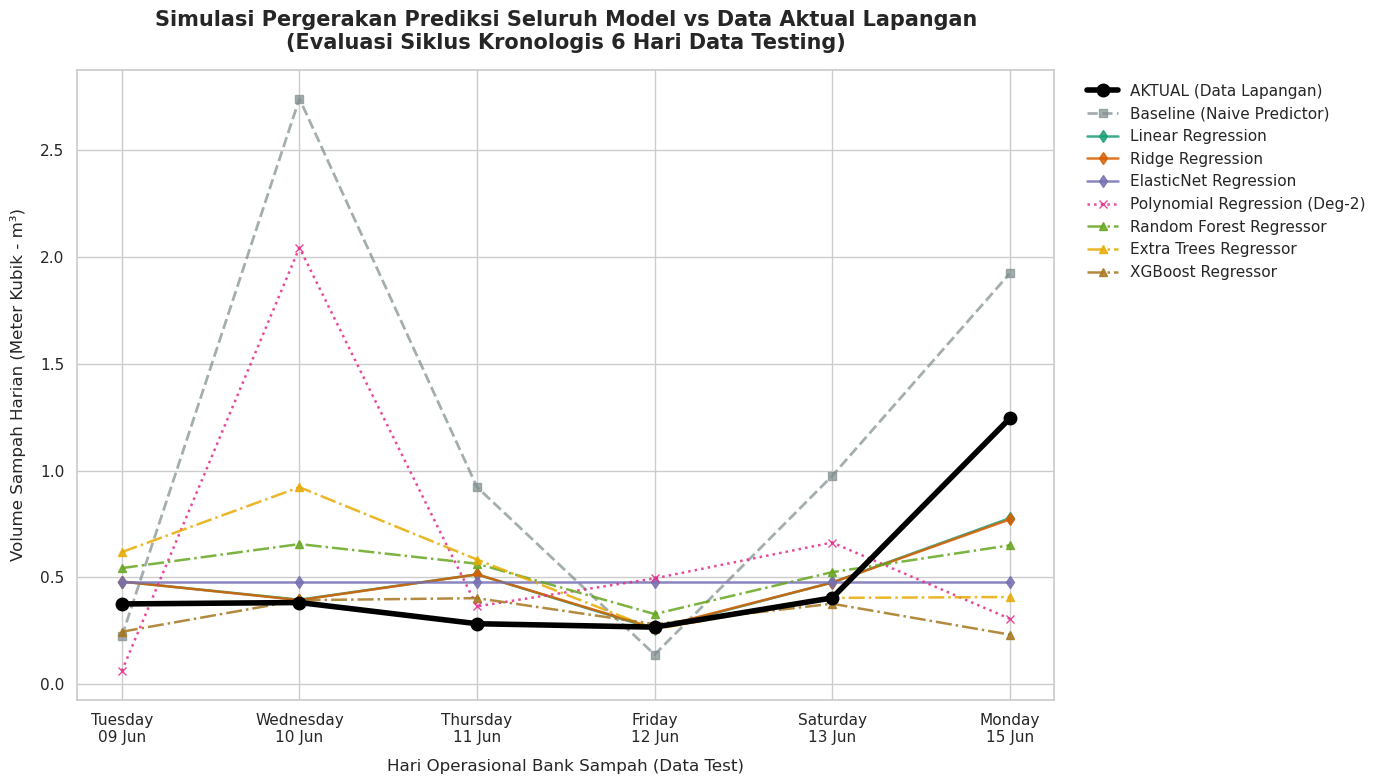

In [21]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(14, 8))

dates_test_dt = pd.to_datetime(dates_test)

x_labels = dates_test_dt.dt.strftime("%A\n%d %b")

plt.plot(
    x_labels,
    y_test_orig,
    label="AKTUAL (Data Lapangan)",
    color="#000000",
    linewidth=4.0,
    marker="o",
    markersize=9,
    zorder=10,  
)

y_pred_naive_orig = np.expm1(X_test["lag_6d"])
plt.plot(
    x_labels,
    y_pred_naive_orig,
    label="Baseline (Naive Predictor)",
    color="#7f8c8d",
    linestyle="--",
    linewidth=2.0,
    marker="s",
    alpha=0.7,
)

colors = sns.color_palette("Dark2", len(models))

for (name, model), color in zip(models.items(), colors):
    model.fit(X_train, y_train_log)
    y_pred_log = model.predict(X_test)
    y_pred_orig = np.expm1(y_pred_log)

    if "Regressor" in name:  
        linestyle = "-."
        marker = "^"
    elif "Polynomial" in name:  
        linestyle = ":"
        marker = "x"
    else:  
        linestyle = "-"
        marker = "d"

    plt.plot(
        x_labels,
        y_pred_orig,
        label=name,
        color=color,
        linestyle=linestyle,
        linewidth=1.8,
        marker=marker,
        alpha=0.85,
    )

plt.title(
    "Simulasi Pergerakan Prediksi Seluruh Model vs Data Aktual Lapangan\n(Evaluasi Siklus Kronologis 6 Hari Data Testing)",
    fontsize=15,
    fontweight="bold",
    pad=15,
)
plt.xlabel("Hari Operasional Bank Sampah (Data Test)", fontsize=12, labelpad=10)
plt.ylabel("Volume Sampah Harian (Meter Kubik - m³)", fontsize=12, labelpad=10)

plt.legend(
    loc="upper left",
    bbox_to_anchor=(1.02, 1),
    frameon=True,
    facecolor="white",
    edgecolor="none",
    fontsize=11,
)

plt.tight_layout()
plt.show()